In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

#1. Linear Time Complexity - O(n)
def print_elements(lst):
    for element in lst:
        print(element)
# Time Complexity: O(n), where n is the length of the list.
myList = [2, 3, 5]

In [2]:
print_elements(myList)

2
3
5


In [3]:
#1. Quadratic Time Complexity - O(n^2)
def print_all_pairs(lst):
    for i in lst:
        for j in lst:
            print(i, j)
# Time Complexity: O(n^2), where n is the length of the list.

In [4]:
print_all_pairs(myList)

2 2
2 3
2 5
3 2
3 3
3 5
5 2
5 3
5 5


In [5]:
#1. Logarithmic Time Complexity - O(log n)
def binary_search(arr, target):
    low = 0
    high = len(arr) - 1
    
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1
    # Time Complexity: O(log n), where n is the length of the sorted array.

In [6]:
#Gaussian Elimination
import numpy as np

def gaussian_elimination(A, b):
    n = len(b)
    
    # Forward elimination
    for i in range(n):
        for j in range(i+1, n):
            factor = A[j][i] / A[i][i]
            for k in range(i, n):
                A[j][k] -= factor * A[i][k]
            b[j] -= factor * b[i]
            
    # Back substitution
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (b[i] - np.dot(A[i][i+1:], x[i+1:])) / A[i][i]
        
    return x

In [7]:
#Matrix Multiplication

def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    
    return C

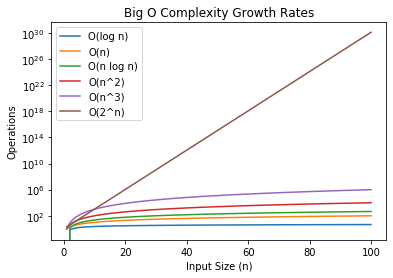

In [8]:
#Visualizing Time Complexities
n = np.linspace(1, 100, 100)

plt.plot(n, np.log(n), label='O(log n)')
plt.plot(n, n, label='O(n)')
plt.plot(n, n * np.log(n), label='O(n log n)')
plt.plot(n, n**2, label='O(n^2)')
plt.plot(n, n**3, label='O(n^3)')
plt.plot(n, 2**n, label='O(2^n)')

plt.yscale('log')  # Logarithmic scale for better visualization
plt.title('Big O Complexity Growth Rates')
plt.xlabel('Input Size (n)')
plt.ylabel('Operations')
plt.legend()
plt.show()

Native Matrix Multiplication time for a  3 x 3 matrix: 0.00020769983530044556
Numpy Matrix Multiplication time for a  3 x 3 matrix: 0.00018172524869441986
Native Matrix Multiplication time for a  6 x 6 matrix: 0.0007446426898241043
Numpy Matrix Multiplication time for a  6 x 6 matrix: 0.0023749656975269318
Native Matrix Multiplication time for a  12 x 12 matrix: 0.006322024390101433
Numpy Matrix Multiplication time for a  12 x 12 matrix: 0.0007811412215232849
Native Matrix Multiplication time for a  24 x 24 matrix: 0.040415775030851364
Numpy Matrix Multiplication time for a  24 x 24 matrix: 5.628541111946106e-05
Native Matrix Multiplication time for a  48 x 48 matrix: 0.13853841461241245
Numpy Matrix Multiplication time for a  48 x 48 matrix: 0.0010057184845209122
Native Matrix Multiplication time for a  96 x 96 matrix: 1.0517180487513542
Numpy Matrix Multiplication time for a  96 x 96 matrix: 0.0004296768456697464
Native Matrix Multiplication time for a  192 x 192 matrix: 8.6243572253

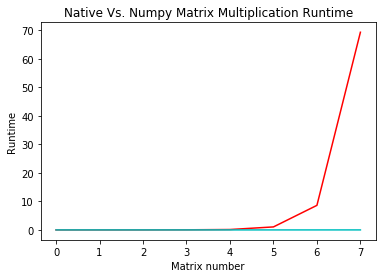

In [17]:
#In-Class Challenge 13
#naive_matrix_multiplication(A, B)
nativeRuntime = []
numpyRuntime = []
matrixNumber = [0,1,2,3,4,5,6,7]
for i in matrixNumber:
    start_time = time.perf_counter()
    A = np.random.rand((3*(2**i)), (3*(2**i)))
    B = np.random.rand((3*(2**i)), (3*(2**i)))
    naive_matrix_multiplication(A, B)
    end_time = time.perf_counter()
    nativeRuntime.append(end_time-start_time)
    print("Native Matrix Multiplication time for a ", (3*(2**i)), "x", (3*(2**i)), "matrix:", end_time-start_time)
    
    start_time = time.perf_counter()
    np.dot(A,B)
    end_time = time.perf_counter()
    numpyRuntime.append(end_time-start_time)
    print("Numpy Matrix Multiplication time for a ", (3*(2**i)), "x", (3*(2**i)), "matrix:", end_time-start_time)

    
plt.plot(matrixNumber, nativeRuntime, 'r', label="Native")
plt.plot(matrixNumber, numpyRuntime, 'c', label="Numpy")

plt.title('Native Vs. Numpy Matrix Multiplication Runtime')
plt.xlabel('Matrix number')
plt.ylabel('Runtime')
plt.show()